# EVALUACIÓN 3 - MODELOS DE CLASIFICACIÓN

**Integrante 1:** Claudio Gaete Flores
**Integrante 2:** Juan Loyola Lagos

**Correo Electrónico Integrante 1:** claudio.gaete2301@alumnos.ubiobio.cl
**Correo Electrónico Integrante 2:** juan.loyola2301@alumnos.ubiobio.cl

**Fecha de Creación:** 11 de Junio de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 2 de la asignatura de Inteligencia Artificial 620454 Sección 1. Donde, en base a un contexto de negocio y un dataset, se crean y entrenan modelos predictivos y se comparan sus índices para seleccionar el mejor.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

# Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

# Preprocesamiento \- Carga de Datos

## Descripción datos

El dataset de estudio contiene un historial de transacciones de la empresa PaySecure\. Contiene datos como:

- Características de la transacción

- Información de transacciones en los últimos 7 días

- Información de balance de cuentas

In [4]:
data = pd.read_csv('../data/ingestion/data_fraude.csv')
data.head()

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.000000,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
1,33.534123,2687.259698,1594,73.618027,20.889169,0,10,0,1,withdrawal,mobile,rural,0,0,0
2,7.607833,1766.666482,60663,75.790821,27.265759,0,5,0,3,purchase,tablet,rural,0,0,0
3,144.069650,1402.597270,32332,61.424568,28.104612,0,15,0,3,withdrawal,mobile,suburban,0,0,0
4,60.279300,193.506482,49575,53.153535,1.000000,3,10,0,1,withdrawal,desktop,rural,0,0,0


In [5]:
data.describe()

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,is_foreign_transaction,is_high_risk_country,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,100.596829,2073.293303,42986.240550,80.827345,30.656022,2.014950,9.958900,0.506400,2.508900,0.103900,0.049950,0.005000
std,100.820016,1382.966545,24953.783088,47.662985,18.730756,1.412596,3.149747,0.715251,1.117624,0.305138,0.217847,0.070535
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.047406,993.130299,21259.000000,45.632425,16.527547,1.000000,8.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,70.059997,2008.125418,42778.500000,79.503855,29.987126,2.000000,10.000000,0.000000,3.000000,0.000000,0.000000,0.000000
75%,138.419340,3022.548675,64656.750000,113.517787,43.476224,3.000000,12.000000,1.000000,4.000000,0.000000,0.000000,0.000000
max,1032.072330,7794.605317,86397.000000,285.026236,107.052797,9.000000,26.000000,5.000000,4.000000,1.000000,1.000000,1.000000


## Objetivo

El objetivo de este trabajo es crear y comparar modelos de clasificación \(Logistic Regression y Decision Tree Classifier\) para predecir si una transacción será un fraude o no\. Esto mediante la variable "is\_fraud" que indica si una transacción fue fraude \(0/1\)

In [6]:
target = "is_fraud"

La predicción se basará en los atributos que tenga una transacción, los cuales los podemos clasificar en:

### Variables Continuas

- transaction\_amount: monto de la transacción

- account\_balance: saldo disponible

- transaction\_time\_seconds: hora del dia de la transacción en segundos

- avg\_transaction\_amount\_7d: promedio transferido ultimos 7 dias

- std\_transaction\_amount\_7d: variabilidad ultimos 7 dias

### Variables Discretas

- transactions\_last\_1h: numero de transacciones en la ultima hora

- transactions\_last\_24h: numero de transacciones en las ultimas 24 horas

- failed\_attempts: intentos fallidos previos

- num\_devices: cantidad de dispositivos distintos usados

In [7]:
# Definición de variables numéricas
features_num = [
    "transaction_amount",
    "account_balance",
    "transaction_time_seconds",
    "avg_transaction_amount_7d",
    "std_transaction_amount_7d",
    "transactions_last_1h",
    "transactions_last_24h",
    "failed_attempts",
    "num_devices_used"
]

### Variables Categóricas

- transaction\_type: Tipo de transacción

- payment

- transfer

- withdrawal

- purchases

- device\_type: Tipo de dispositivo en el cual se realizó la transacción

- mobile

- desktop

- tablet

- location\_region: Tipo de lugar de origen de la transacción

- urban

- suburban

- rural

- is\_foreign\_transaction: Indicador de transacción internacional \(0/1\)

- is\_high\_risk\_country: Indicador de transacción con un país de alto riesgo como origen \(0/1\)

In [8]:
# Definición de variables categóricas
features_cat = [
    "transaction_type",
    "device_type",
    "location_region",
    "is_foreign_transaction",
    "is_high_risk_country"
]

# Preprocesamiento \- Entendimiento de los datos

## Distribución de la variable objetivo

Primero debemos analizar la distribución de la variable objetivo para determinar si habrá un desbalance de clases en las predicciones\.

Al realizar su gráfico de torta, notamos que el 99\.5% de las transacciones son legítimas y solo el 0\.5% son fraudulentas\. Lo que implica que existe un fuerte desbalance donde la clase negativa es extremadamente superior\.

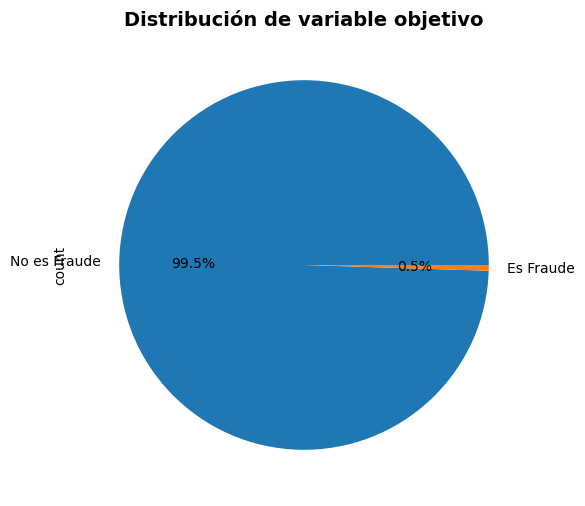

In [9]:
data[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No es Fraude', 'Es Fraude'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()


## Detección de inconsistencias

### Variables numéricas

Para definir las inconsistencias, primero debemos decir que las variables cuantitativas \(continuas y discretas\) del dataset deben ser mayores o iguales a 0\. Porque las variables representan unidades de dinero \(transacción y saldo\), tiempo y contadores de acciones \(intentos fallidos y dispositivos distintos usados\)\.

Al ejecutar el código para encontrar inconsistencias, este no nos arroja resultados\. Por lo que los datos cuantitativos del dataset son consistentes\.

In [10]:
inconsistentes = data[(data[features_num] < 0).any(axis=1)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud


### Variables categóricas

Las variables categóricas son consistentes si sus valores se encuentran en las listas descritas en la carga de datos\. Por lo que revisamos los valores únicos de cada variable\.

Al ejecutar el código, vemos que cada una contiene los valores listados anteriormente\. Por lo que los datos cualitativos del dataset son consistentes\.

In [11]:
for columna in features_cat:
  print(f"{columna:<26}: {data[columna].unique()}")

transaction_type          : ['transfer' 'withdrawal' 'purchase' 'payment']
device_type               : ['mobile' 'tablet' 'desktop']
location_region           : ['rural' 'suburban' 'urban']
is_foreign_transaction    : [1 0]
is_high_risk_country      : [0 1]


## Detección de nulos

Debemos analizar la presencia de valores nulos en el dataset\. Con el propósito de analizar si es necesario imputar datos en la fase de limpieza\.

Al ejecutar el código, vemos que existen 20000 tuplas en total y que cada variable tiene 20000 valores no nulos\. Por lo que el dataset no cuenta con nulos y no es necesario imputar

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_amount         20000 non-null  float64
 1   account_balance            20000 non-null  float64
 2   transaction_time_seconds   20000 non-null  int64  
 3   avg_transaction_amount_7d  20000 non-null  float64
 4   std_transaction_amount_7d  20000 non-null  float64
 5   transactions_last_1h       20000 non-null  int64  
 6   transactions_last_24h      20000 non-null  int64  
 7   failed_attempts            20000 non-null  int64  
 8   num_devices_used           20000 non-null  int64  
 9   transaction_type           20000 non-null  object 
 10  device_type                20000 non-null  object 
 11  location_region            20000 non-null  object 
 12  is_foreign_transaction     20000 non-null  int64  
 13  is_high_risk_country       20000 non-null  int

## Detección de valores atípicos

Como los datos vienen limpios \(consistentes y sin nulos\), no es necesario analizar los atípicos ya que no se imputarán valores con la media\. Considerando que uno intenta eliminar los atípicos con el fin de aumentar la representatividad del promedio\.

## Detección de duplicados

Como no se cuenta con un identificador de transacción en el dataset, no se puede determinar si una tupla está duplicada o si ambas transacciones coinciden de casualidad\. Por lo que no se analizará la duplicidad\.

# Preprocesamiento

## Preparación de Pipeline de Preprocesamiento

El preprocesador se divide para manejar las variables numéricas y categóricas\. En este caso, cada transformador se encargará de imputar los valores \(por si es que el dataset viene con valores nulos\) y de codificar las variables categóricas\. Además, se crearán transformadores que escalarán las variables numéricas para que los modelos como LogisticRegression funcionen correctamente\.

In [13]:
# Preprocesamiento numérico con escalamiento: imputación+estandarización
numeric_transformer_es = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico con codificación: imputación+one-hot encoding
categorical_transformer_cod = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# Preprocesamiento numérico sin escalamiento: imputación
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

## Creación del preprocesador\.

Luego, armamos los preprocesadores donde uno escala y el otro no, a partir de los transformadores de variables numéricas y categóricas\. En este caso, solo se transformarán las variables categóricas que no son booleanas \(las que son 0/1 no necesitan codificarse\)\.

In [14]:
features_cat_transform = [
    "transaction_type",
    "device_type",
    "location_region"
]

preprocessor_EsCod = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_es, features_num),
        ("cat", categorical_transformer_cod, features_cat_transform)
    ],
    remainder="passthrough"
)
preprocessor_EsCod.set_output(transform="pandas")

preprocessor_Cod = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer_cod, features_cat_transform)
    ],
    remainder="passthrough"
)
preprocessor_Cod.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['transaction_amount', 'account_balance',
                                  'transaction_time_seconds',
                                  'avg_transaction_amount_7d',
                                  'std_transaction_amount_7d',
                                  'transactions_last_1h',
                                  'transactions_last_24h', 'failed_attempts',
                                  'num_devices_used']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['transaction_type', 'device_type',
                                  'location_region'])])

## División de datos para entrenamiento y prueba

Debemos dividir los datos en el dataset de tal forma que "X" contenga las variables predictoras e "y" la variable resultado u objetivo\.

In [15]:
X = data[features_num + features_cat]
y = data[target]

Luego, dividimos los datos en un  80% para entrenamiento del modelo del modelo \(train\) y y 20% para probar el modelo entrenado \(test\)\. Aquí usamos el parámetro "stratify" para repartir los valores "y" equitativamente entre el entrenamiento y prueba, considerando el desbalance extremo de clases \(99\.5% negativo vs 0\.5% positivo\)\.

In [16]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

# Entrenamiento y optimización de modelos

Los modelos categóricos de dos clases se evalúan mediante los parámetros "accuracy", "f1\-score", "precision", "recall" y "roc auc"\. La función "evaluar" nos devuelve estos parámetros resultado de entrenar un modelo\.

In [17]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

In [18]:
def mostrarMetricas(metricas: dict):
    print(f"{'Métrica':<20} {'Valor':<10}")
    print(f"{'Accuracy':<20}: {metricas['accuracy']:.4f}")
    print(f"{'F1 Score:':<20}: {metricas['f1']:.4f}")
    print(f"{'ROC AUC Score':<20}: {metricas['roc_auc']:.4f}")
    print(f"{'Precision':<20}: {metricas['precision']:.4f}")
    print(f"{'Recall':<20}: {metricas['recall']:.4f}")

## Logistic Regression

Primero, definimos el pipeline que permite entrenar y probar el modelo predictivo Logistic Regression, el cual necesita el preprocesador que transforma y escala/codifica las variables numéricas y categóricas para funcionar correctamente\.

In [19]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_lr = Pipeline(steps=[
    ("preprocesador", preprocessor_EsCod),
    ("modelo", LogisticRegression())
])

### Grilla de hiperparámetros

Especifiquemos los posibles valores para cada hiperparámetro:

- penalty: Tipo de penalización para variables predictoras con menos correlación con el objetivo\. En este caso, se usa la penalización "l2" \(Ridge\)

- C: Valor inverso de penalización para las variables\. A menor valor, más penalización\.

- max\_iter: Iteraciones máximas para ajustar los pesos de las variables en el modelo

- class\_weight: Peso que tendrá cada clase o categoría a predecir\. En este caso será "balanced" para balancear la desigualdad de clases encontrada \(99\.5% No vs 0\.5% Sí\)\.

In [20]:
param_grid_lr = {
      'modelo__penalty': ['l2'],
      'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100],
      'modelo__max_iter': [500, 1000],
      'modelo__class_weight': ['balanced']
    }

### Aplicación de GridSearchCV

Al aplicar la grilla en el entrenamiento del modelo LR, separaremos los datos de entrenamiento para un test en 5 partes y evaluaremos los mejores hiperparámetros según su puntaje en F1 \(puntaje útil cuando las clases están desbalanceadas y los dos errores son importantes\)\.

In [21]:
grid_lr = GridSearchCV(
    pipeline_modelo_lr,
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('escalado',
                                                                                          StandardScaler())]),
                                                                         ['transaction_amount',
                                                                          'account_balance',
                                                                          'transaction_time_seconds',
                                                                          'avg_transaction_amount_7d',...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['transaction_type',
                                                                          'device_type',
                                                                          'location_region'])])),
                                       ('modelo', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'modelo__class_weight': ['balanced'],
                         'modelo__max_iter': [500, 1000],
                         'modelo__penalty': ['l2']},
             scoring='f1')

Una vez entrenado el modelo aplicando la grilla, podemos estimar cuál combinación de valores de dichos hiperparámetros es la mejor para el modelo\. En este caso la mejor combinación en la siguiente:

In [22]:
grid_lr.best_params_

{'modelo__C': 100,
 'modelo__class_weight': 'balanced',
 'modelo__max_iter': 500,
 'modelo__penalty': 'l2'}

Ahora que hemos especificado la mejor combinación de hiperparámetros, podemos evaluar las métricas del modelo\. En este caso, F1\-Score es la mejor métrica ya que contamos con un desbalance de clases altamente elevado \(0,5% es fraude\)\. Aunque lo más relevante es reducir la cantidad de falsos negativos, ya que estos representan pérdidas económicas:

- Accuracy: El 99\.78% de las predicciones son correctas

- F1 Score: Existe un buen balance entre la detección de positivos y la equivocación \(81\.63%\)

- ROC AUC Score: El modelo es 99\.99% perfecto para predecir

- Precision: El 68\.97% de los positivos predecidos eran correctos

- Recall: El 100% de los positivos \(casos de fraudes\) se detectaron correctamente

De los resultados, podemos decir que el modelo es perfecto para detectar casos de fraudes \(100% recall\) y, aunque solo el 68\.97% de los positivos detectados eran correctos \(precision\), el F1\-Score muestra que existe un buen balance entre los errores \(considerando la proporción de la clase negativa\) y la detección de positivos\. Pero se debe considerar que un modelo casi perfecto puede significar que esté memorizando los datos de prueba y entrenamiento en lugar de generalizar, lo que le quita credibilidad en casos reales\.

In [23]:
best_model_lr = grid_lr.best_estimator_
# Evaluación
metricas_lr = evaluar(best_model_lr, X_train, X_test, y_train, y_test)
mostrarMetricas(metricas_lr)

Métrica              Valor     
Accuracy            : 0.9978
F1 Score:           : 0.8163
ROC AUC Score       : 0.9999
Precision           : 0.6897
Recall              : 1.0000


Al analizar el puntaje del modelo en entrenamiento y en testing, vemos que el modelo es casi perfecto y su efecto de overfitting es casi nulo \(99\.89% en entrenamiento vs 99\.78% en testing\)\.

In [24]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.99887
Score del modelo en test                :0.99775


## DecisionTreeClassifier

Ahora, definimos el pipeline que permite entrenar y probar el modelo predictivo Decision Tree Classifier, el cual necesita el preprocesador que transforma las variables numéricas y categóricas \(no necesita el escalamiento de variables numéricas, pero sí la codificación de variables categóricas\)\.

In [25]:
# Crea el pipeline final (modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("preprocesador", preprocessor_Cod),
    ("modelo", DecisionTreeClassifier())
])

### Grilla de hiperparámetros

Luego, definimos la grilla de hiperparámetros para encontrar los mejores:

- max\_depth: Indica la profundidad máxima del árbol de decisiones

- min\_samples\_split: Mínimo de ejemplos para que un nodo pueda dividirse

- min\_samples\_leaf: Mínimo de ejemplos para que un nodo sea una hoja

- class\_weight: Penalización de clases\. En este caso será "balanced" debido al desbalance de clases\.

In [26]:
param_grid_dt = {
    "modelo__max_depth": range(3,10),
    "modelo__min_samples_split": [2, 5, 10, 20, 50],
    "modelo__min_samples_leaf": [1, 2, 5, 10, 20],
    "modelo__class_weight": ["balanced"]
}

### Aplicación GridSearchCV 

Al aplicar la grilla en el entrenamiento del modelo DTC, separaremos los datos de entrenamiento para prueba en 5 partes y evaluaremos los mejores hiperparámetros según su puntaje en F1 \(puntaje útil cuando las clases están desbalanceadas y sus errores son importantes\)\.

In [27]:
grid_dt = GridSearchCV(
    pipeline_modelo_dtc,
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['transaction_amount',
                                                                          'account_balance',
                                                                          'transaction_time_seconds',
                                                                          'avg_transaction_amount_7d',
                                                                          'std_transaction_amount_7d',
                                                                          't...
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['transaction_type',
                                                                          'device_type',
                                                                          'location_region'])])),
                                       ('modelo', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': ['balanced'],
                         'modelo__max_depth': range(3, 10),
                         'modelo__min_samples_leaf': [1, 2, 5, 10, 20],
                         'modelo__min_samples_split': [2, 5, 10, 20, 50]},
             scoring='f1')

Una vez entrenado el modelo aplicando la grilla, podemos estimar cuál combinación de valores de dichos hiperparámetros es la mejor para el modelo\. En este caso la mejor combinación en la siguiente:

In [28]:
grid_dt.best_params_

{'modelo__class_weight': 'balanced',
 'modelo__max_depth': 9,
 'modelo__min_samples_leaf': 1,
 'modelo__min_samples_split': 2}

Ahora que hemos especificado la mejor combinación de hiperparámetros, podemos evaluar las métricas del modelo\. En este caso, F1\-Score es la mejor métrica ya que contamos con un desbalance de clases altamente elevado \(0,5% es fraude\)\. Aunque lo más relevante es reducir la cantidad de falsos negativos, ya que estos representan pérdidas económicas\.

De los resultados, tenemos:

- Accuracy: El 97\.60% de las predicciones son correctas

- F1 Score: Existe un balance pobre entre la detección de positivos y la equivocación \(15\.79%\)

- ROC AUC Score: El modelo es 71\.78% perfecto para predecir

- Precision: El 9\.57% de los positivos predecidos eran correctos

- Recall: El 45\.00% de los positivos \(casos de fraudes\) se detectaron correctamente

De los resultados se puede notar la falencia que tienen puntajes como Accuracy y ROC\-AUC, ya que estos tienen valores correctos al predecir correctamente la clase mayoritaria \(no es fraude\)\. Pero solo se detectó el 45% de los casos de fraude reales y solo el 9\.57% eran correctos\. Por estos valores, su F1\-Score muestra el rendimiento deficiente del modelo con un 15\.79%\.

In [29]:
# Evaluación
best_model_dt = grid_dt.best_estimator_
metricas_dtc = evaluar(best_model_dt, X_train, X_test, y_train, y_test)
mostrarMetricas(metricas_dtc)

Métrica              Valor     
Accuracy            : 0.9760
F1 Score:           : 0.1579
ROC AUC Score       : 0.7178
Precision           : 0.0957
Recall              : 0.4500


Al analizar el puntaje del modelo en entrenamiento y en testing, vemos que el modelo tiene un efecto de overfitting casi nulo \(96\.64% en entrenamiento vs 97\.53% en testing\)\.

In [30]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model_dt.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model_dt.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.97788
Score del modelo en test                :0.97600


## Evaluación del mejor modelo

Teniendo ya medidas las métricas de ambos modelos después de haber aplicado GridSearchCV, podemos evaluar cuál es el mejor modelo basado el F1\-Score\. Métrica elegida para justificar la predictibilidad de un modelo basado en el desbalance de clases del dataset\.

Podemos ver que el modelo de Logistic Regression presenta un mejor rendimiento y es elegido como el mejor modelo, teniendo un F1\-Score significativamente mejor \(81,6% vs 15,8%\)\.

In [31]:
best_model = best_model_lr if metricas_lr["f1"] > metricas_dtc["f1"] else best_model_dt
best_model

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['transaction_amount',
                                                   'account_balance',
                                                   'transaction_time_seconds',
                                                   'avg_transaction_amount_7d',
                                                   'std_transaction_amount_7d',
                                                   'transactions_last_1h',
                                                   'transactions_last_24h',
                                                   'failed_attempts',
                                                   'num_devices_used']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['transaction_type',
                                                   'device_type',
                                                   'location_region'])])),
                ('modelo',
                 LogisticRegression(C=100, class_weight='balanced',
                                    max_iter=500))])

# Evaluación base del modelo elegido

Para evaluar el modelo elegido, definiremos la función "predecirUmbral" la cual calculará los puntajes como F1\-Score y Accuracy de un modelo elegido basado en un umbral\.

In [32]:
def predecirUmbral(modelo: BaseEstimator, X_test: np.array, y_test: np.array, umbral: float):
    y_prob = modelo.predict_proba(X_test)[:,1]

    return {
        "y_test": y_test,
        "y_prob": y_prob,
        "y_pred": (y_prob >= umbral).astype(int)
    }

Se usará una función que permita devolver las métricas de una predicción

In [33]:
def obtenerMetricas(y_test: np.array, y_pred: np.array, y_prob: np.array):
  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

También, definiremos la función "verMatrizConfusionUmbral" que nos mostrará el número de valores predecidos \(casos de fraudes\) y su cantidad de errores al predecir\.

In [34]:
def verMatrizConfusionUmbral(y_test: np.array, y_pred: np.array, umbral: float):
  """
  Obtiene la matriz de confusión usando un determinado umbral

  Parámetros
  ----------
  umbral : float
    Umbral para la clasificación.
  """
  cm = confusion_matrix(y_test, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No es fraude", "Sí es fraude"])
  disp.plot(cmap="Blues")
  plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
  plt.xlabel("Predicción", fontweight="bold", fontsize=12)
  plt.ylabel("Valor real", fontweight="bold", fontsize=12)
  plt.show()

Por defecto, los modelos tienen un umbral del 50%\. Por lo que probaremos el modelo elegido con este umbral\.

In [35]:
umbral = 0.5

Al calcular sus métricas, vemos que los puntajes son iguales a los obtenidos durante la elección del mejor modelo\. Más específicamente, cuando se calcularon las métricas del modelo LogisticRegression con los mejores hiperparámetros encontrados\. Lo que confirma que el umbral por defecto de los modelos es de 0\.5

- Accuracy: El 99\.78% de las predicciones son correctas

- F1 Score: Existe un buen balance entre la detección de positivos y la equivocación \(81\.63%\)

- Precision: El 68\.97% de los positivos predecidos eran correctos

- Recall: El 100% de los positivos \(casos de fraudes\) se detectaron correctamente

In [36]:
resultados = predecirUmbral(best_model, X_test,y_test, umbral)
metricasUmbral = obtenerMetricas(resultados["y_test"],resultados["y_pred"],resultados["y_prob"])
mostrarMetricas(metricasUmbral)

Métrica              Valor     
Accuracy            : 0.9978
F1 Score:           : 0.8163
ROC AUC Score       : 0.9999
Precision           : 0.6897
Recall              : 1.0000


Al realizar la predicción y ver la matriz, vemos que los 20 casos de fraude fueron detectados exitosamente\. Pero hubo 9 casos que el modelo marcó como fraude a transacciones legítimas\.

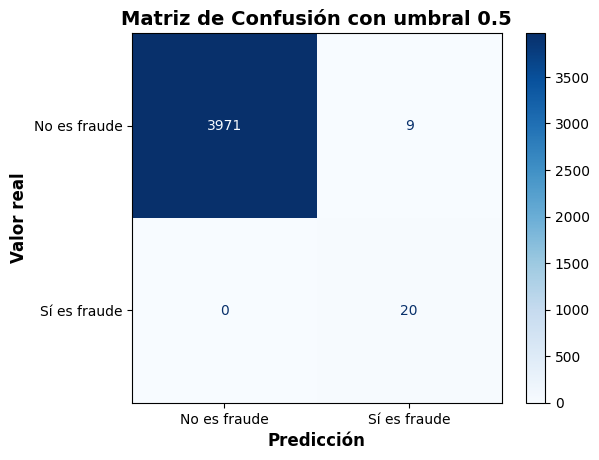

In [37]:
verMatrizConfusionUmbral(resultados["y_test"],resultados["y_pred"], umbral)

En el contexto del negocio, este umbral sirve para predecir correctamente los casos de fraude \(recall del 100%\)\. Pero las 9 transacciones legítimas que fueron marcadas como fraudes representan 9 experiencias negativas para los clientes\. Lo que podría generar un abandono de la plataforma\.

Aunque solo sean 9 falsos positivos de las 3980 transacciones, podemos buscar un umbral que mejore estos resultados\.

# Ajuste de threshold

## Evaluación con distintos valores de umbrales

En esta sección, ajustaremos el umbral \(threshold\) a 0\.3, 0\.5 y 0\.7 y así encontrar el mejor para el modelo considerando el contexto de negocio

### Predicción con umbral 0\.3

Ahora usaremos un umbral del 30%\. O sea, aumentará la probabilidad de que una transacción sea marcada como fraude\.

In [38]:
umbral = 0.3

Al calcular sus métricas, vemos que dos métricas importantes del modelo disminuyeron:

- F1 Score: Disminuye del 81\.63% al 78\.43%

- Precision: El 64\.52% de los positivos predecidos eran correctos\. Disminución de rendimiento comparado al umbral del 0\.5 \(68\.97%\)

- Recall: El 100% de los positivos \(casos de fraudes\) se detectaron correctamente \(no varía\)

In [39]:
resultados = predecirUmbral(best_model, X_test,y_test, umbral)
metricasUmbral = obtenerMetricas(resultados["y_test"],resultados["y_pred"],resultados["y_prob"])
mostrarMetricas(metricasUmbral)

Métrica              Valor     
Accuracy            : 0.9972
F1 Score:           : 0.7843
ROC AUC Score       : 0.9999
Precision           : 0.6452
Recall              : 1.0000


Al realizar la predicción y ver la matriz, vemos que los 20 casos de fraude fueron detectados exitosamente\. Pero hubo 11 casos que el modelo marcó como fraude pero no lo eran\.

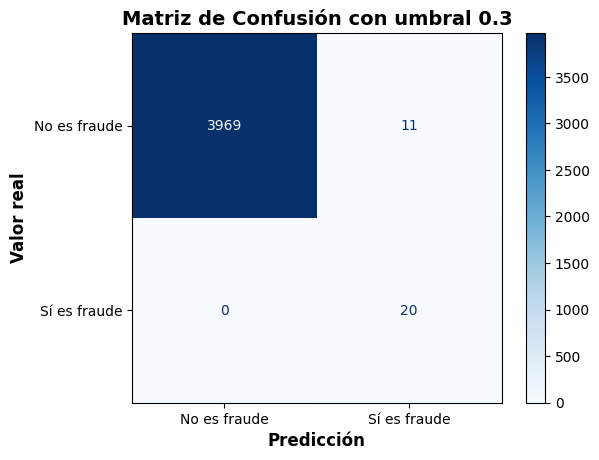

In [40]:
verMatrizConfusionUmbral(resultados["y_test"],resultados["y_pred"], umbral)

In [41]:
# guardamos las predicciones
pd.DataFrame(resultados).to_csv('../data/prediction/bestModel_'+str(umbral)+'_theshold.csv', index=False)

### Predicción con umbral 0\.5

Ahora usaremos un umbral del 50%\. O sea,el umbral por defecto

In [42]:
umbral = 0.5

Al calcular sus métricas, vemos que los puntajes son iguales a los obtenidos durante la elección del mejor modelo\.

In [43]:
resultados = predecirUmbral(best_model, X_test,y_test, umbral)
metricasUmbral = obtenerMetricas(resultados["y_test"],resultados["y_pred"],resultados["y_prob"])
mostrarMetricas(metricasUmbral)

Métrica              Valor     
Accuracy            : 0.9978
F1 Score:           : 0.8163
ROC AUC Score       : 0.9999
Precision           : 0.6897
Recall              : 1.0000


Al realizar la predicción y ver la matriz, vemos que los 20 casos de fraude fueron detectados exitosamente y 9 casos que el modelo marcó como fraude pero no lo eran\. \(Caso base\)

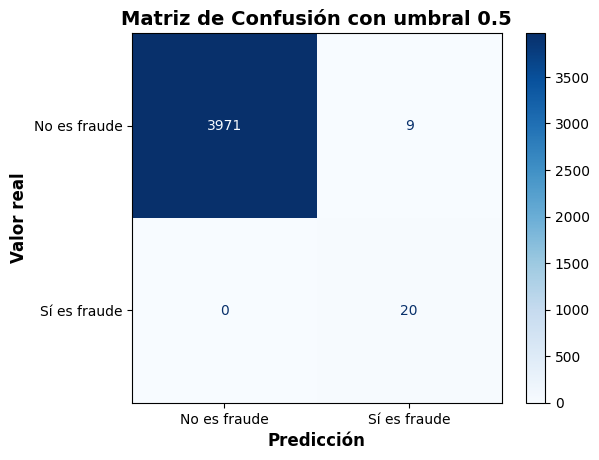

In [44]:
verMatrizConfusionUmbral(resultados["y_test"],resultados["y_pred"], umbral)

In [45]:
# guardamos las predicciones
pd.DataFrame(resultados).to_csv('../data/prediction/bestModel_'+str(umbral)+'_theshold.csv', index=False)

### Predicción con umbral 0\.7

Ahora usaremos un umbral del 70%\. O sea, disminuirá la probabilidad de que una transacción sea marcada como fraude\.

In [46]:
umbral = 0.7

Al calcular sus métricas, vemos que dos métricas importantes del modelo aumentaron con respecto al 0\.5:

- F1 Score: Pasa del 81\.63% al 83\.33%

- Precision: El 71\.43% de los positivos predecidos eran correctos\. Aumento de rendimiento comparado al umbral del 0\.5 \(68\.97%\)

- Recall: El 100% de los positivos \(casos de fraudes\) se detectaron correctamente \(no varía\)

In [47]:
resultados = predecirUmbral(best_model, X_test,y_test, umbral)
metricasUmbral = obtenerMetricas(resultados["y_test"],resultados["y_pred"],resultados["y_prob"])
mostrarMetricas(metricasUmbral)

Métrica              Valor     
Accuracy            : 0.9980
F1 Score:           : 0.8333
ROC AUC Score       : 0.9999
Precision           : 0.7143
Recall              : 1.0000


Al realizar la predicción y ver la matriz, vemos que los 20 casos de fraude fueron detectados exitosamente y 8 casos que el modelo marcó como fraude pero no lo eran\.

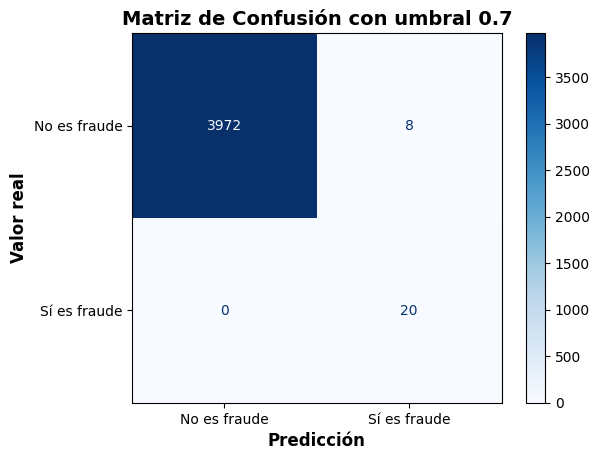

In [48]:
verMatrizConfusionUmbral(resultados["y_test"],resultados["y_pred"], umbral)

In [49]:
# guardamos las predicciones
pd.DataFrame(resultados).to_csv('../data/prediction/bestModel_'+str(umbral)+'_theshold.csv', index=False)

## Análisis comparativo

Teniendo las métricas de los 3 modelos con cada valor de threshold correspondiente, podemos hacer las observaciones necesarias\. La cantidad de falsos negativos no se ve afectada a lo largo de los 3 cambios de threshold, esta se mantiene en 0\. Lo que sí se ve afectado es la cantidad de falsos positivos, ya que empezamos con un total de 11 falsos positivos y este disminuye a 9 con un threshold de 0\.5 y posteriormente disminuye a 8 con un threshold de 0\.7\.  La métrica de Precision va aumentando levemente mientras aumentamos el valor del umbral, ya que disminuye la cantidad de falsos positivos, pasando de 64,5% con el umbral mas pequeño asignado a 71,4% con el umbral mayor asignado\. Recall permanece en el mismo valor \(1\.0\) ya que la cantidad de falsos negativos se mantiene estable a lo largo de los 3 modelos \(0\)\.

## Decisión de negocio

El modelo mas optimo a escoger es aquel con umbral 0\.7, ya que, si observamos nuestra métrica de Recall podemos ver que sin importar el umbral asignado la cantidad de falsos negativos será 0 \(no hay riesgo de fraude que se detecte como transacción legitima\)\. Si observamos los resultados anteriores podemos ver que un threshold de 0\.7 resulta en la menor cantidad resultante de falsos positivos \(mejor Precision de 71,4%\)\. Esto se traduce en disminuir la cantidad de sanciones hacia usuarios que realizan una transacción legítima que pueden resultar molestos a usuarios sin intenciones de fraude\.

# Conclusiones

## ¿Qué modelo resultó mejor y por qué? 

De todos los modelos vistos anteriormente, el mejor en nuestro caso es el modelo Logistic Regression con threshold de 0\.7, no solo porque presenta un Recall de 1\.0, lo que se traduce en una detección de todos los fraudes reales, sino también porque posee la mayor métrica de Precision con un 71,4%, disminuyendo la cantidad de predicciones erróneas sobre transacciones legítimas\.

## ¿Qué variable\(s\) parecen más influyentes? 

De las variables involucradas en los datos de entrada, podemos observar cuales son las mas influyentes a través de la correlación que estas posean respecto a la variable objetivo \(is\_fraud\) y estas son: is\_high\_risk\_country, failed\_attempts, transactions\_last\_1h, is\_foreign\_transaction\. Lo que tiene sentido, ya que estas variables se relacionan directamente con las características de la transacción, origen y  comportamiento del usuario\. Esto puede marcar la diferencia entre un usuario común y uno fraudulento\. Con la correlación de las variables categorías podemos observar que las transferencias suelen ser los tipos de transacciones mas fraudulentas y las transacciones fraudulentas son mas probables a ser realizadas en dispositivos móviles\.

In [57]:
data.groupby("transaction_type")[target].mean().sort_values()

transaction_type
withdrawal    0.003189
purchase      0.003387
payment       0.004290
transfer      0.009077
Name: is_fraud, dtype: float64

In [58]:
data.groupby("device_type")[target].mean().sort_values()

device_type
tablet     0.000987
desktop    0.001671
mobile     0.007339
Name: is_fraud, dtype: float64

In [59]:
data.groupby("location_region")[target].mean().sort_values()

location_region
urban       0.004229
rural       0.005055
suburban    0.005712
Name: is_fraud, dtype: float64

In [60]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

is_fraud                     1.000000
is_high_risk_country         0.201771
failed_attempts              0.121273
transactions_last_1h         0.099618
is_foreign_transaction       0.098992
transaction_amount           0.050008
transactions_last_24h        0.001600
transaction_time_seconds     0.001429
avg_transaction_amount_7d    0.000671
account_balance             -0.000361
num_devices_used            -0.008810
std_transaction_amount_7d   -0.012300
Name: is_fraud, dtype: float64

## ¿Qué mejoras propondría al sistema?

El modelo posee una buena capacidad predictiva, pero podría mejorarse aun más\. Una de las opciones para mejorar las métricas del modelo es  la implementación de feature engineering que puedan relacionarse con el comportamiento histórico del cliente\. Por otro lado, se podría considerar el enriquecimiento de los datos, donde además de las variables ya mencionadas, se tomen en cuenta posibles correos electrónicos desechables, direcciones IPs sospechosas o agregar una verificación de identidad al momento de crear una cuenta\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=294efba9-b438-4e4c-87c1-21048d031afc' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>